In [ ]:

import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits

from matplotlib.patches import Circle

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow1, imshow2, imshow3
from scoob_llowfsc import utils
from scoob_llowfsc import iefc
import scoob_llowfsc.scoob_model as scoobm

wfe_data = utils.load_pickle('sim-data/example_wfe_data.pkl')

Oversampling > 2x suggested for reliable results in Fresnel propagation.


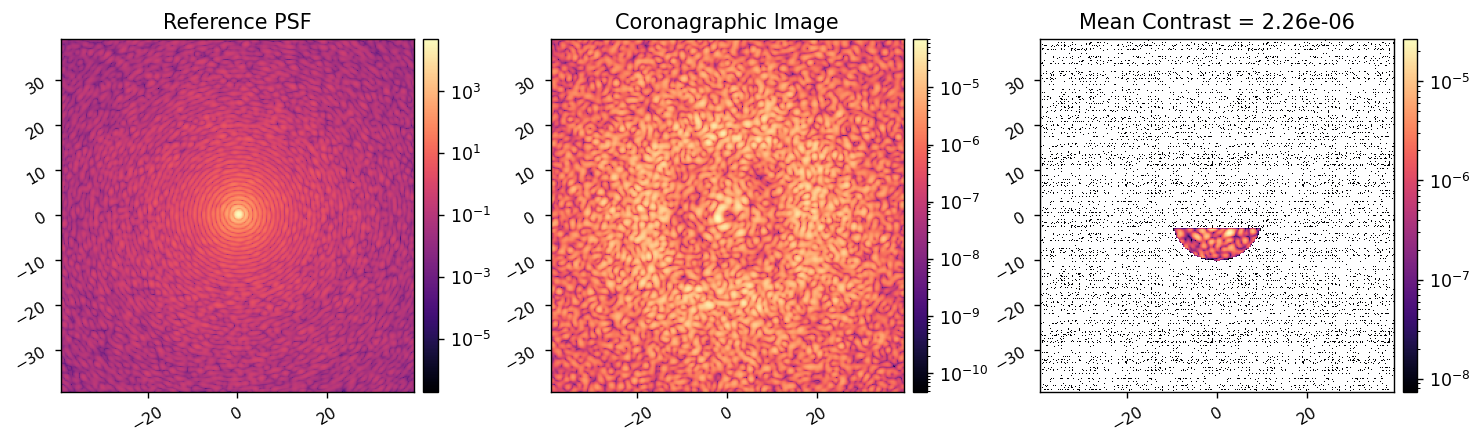

In [19]:
reload(scoobm)
reload(utils)

M = scoobm.single()
M.ncamsci = 256

M.PREFPM_AMP = wfe_data['PREFPM_AMP']
M.PREFPM_OPD = wfe_data['PREFPM_OPD']

M.POSTFPM_AMP = wfe_data['POSTFPM_AMP']
M.POSTFPM_OPD = wfe_data['POSTFPM_OPD']

M.RLS_AMP = wfe_data['RLS_AMP']
M.RLS_OPD = wfe_data['RLS_OPD']

M.dm_ref = wfe_data['DM_FLAT']
M.reset_dm()

iwa = 3
owa = 10
control_mask = utils.create_annular_focal_plane_mask(
    M.ncamsci, 
    M.camsci_pxscl_lamD, 
    iwa, 
    owa,  
    edge=iwa,
    rotation=90,
)
# imshow1(control_mask, pxscl=M.camsci_pxscl_lamD)

M.use_vortex = 0
ref_psf = M.snap_camsci()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = 1
camsci_im0 = M.snap_camsci()
mean_contrast0 = xp.mean(camsci_im0[control_mask])

imshow3(
    ref_psf, camsci_im0, camsci_im0*control_mask,
    'Reference PSF', 'Coronagraphic Image', f'Mean Contrast = {mean_contrast0:.2e}', 
    pxscl=M.camsci_pxscl_lamDc,
    lognorm=1, 
)





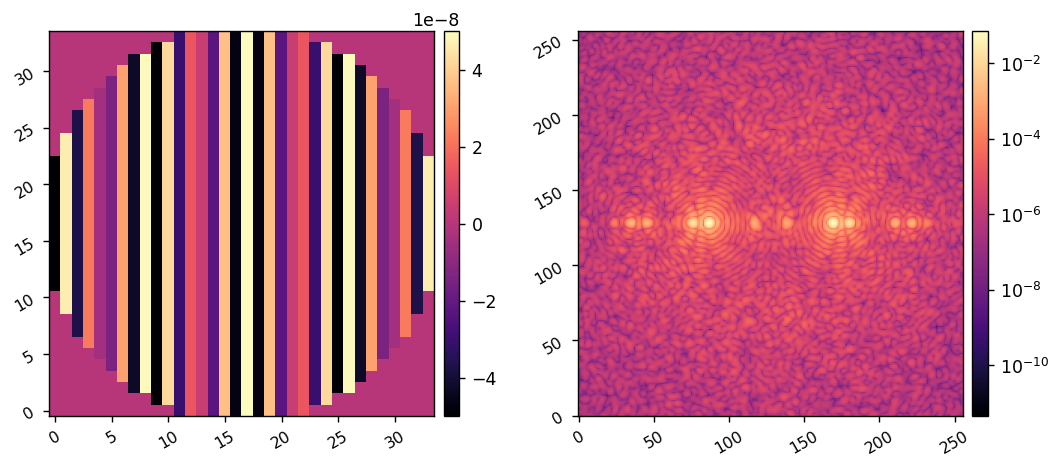

In [17]:
command = 50e-9 * utils.make_fourier_command(15,0) * M.dm_mask
M.set_dm(command)
im = M.snap_camsci()
imshow2(command, im, lognorm2=1)

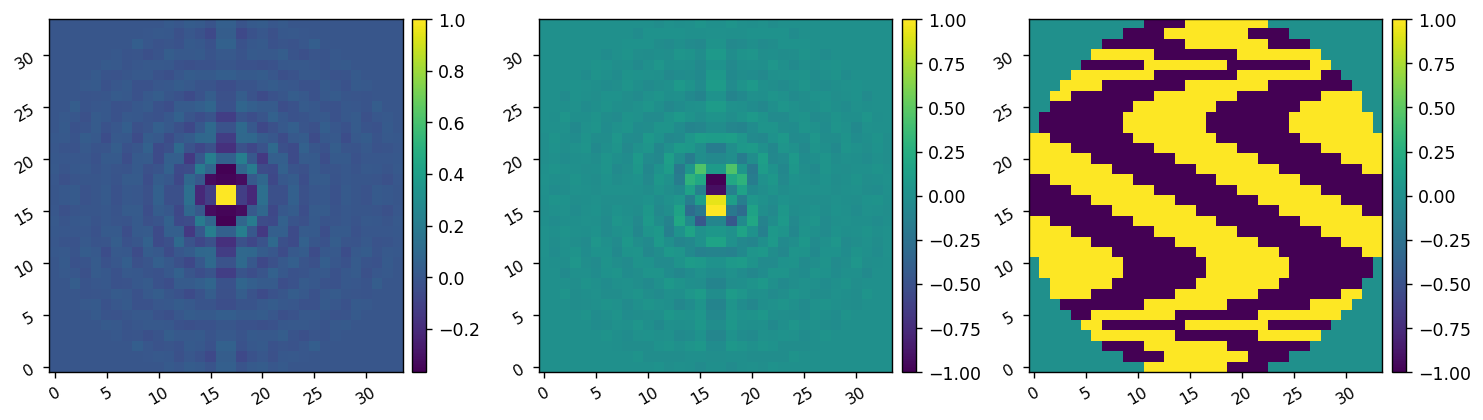

In [20]:
reload(utils)
fourier_probes = utils.create_fourier_probes(
    M.dm_mask, 
    M.ncamsci, M.camsci_pxscl_lamDc, 
    iwa-1, owa+2, 
    # iwa-1, 16, 
    rotation=90,
    use_weighting=True,
    nprobes=2,
)

calib_modes = utils.create_hadamard_modes(M.dm_mask)

imshow3(fourier_probes[0], fourier_probes[1], calib_modes[8], cmap1='viridis', cmap2='viridis', cmap3='viridis')

Calibrating iEFC...
	Calibrated mode 1024/1024 in 124.299s
Calibration complete.


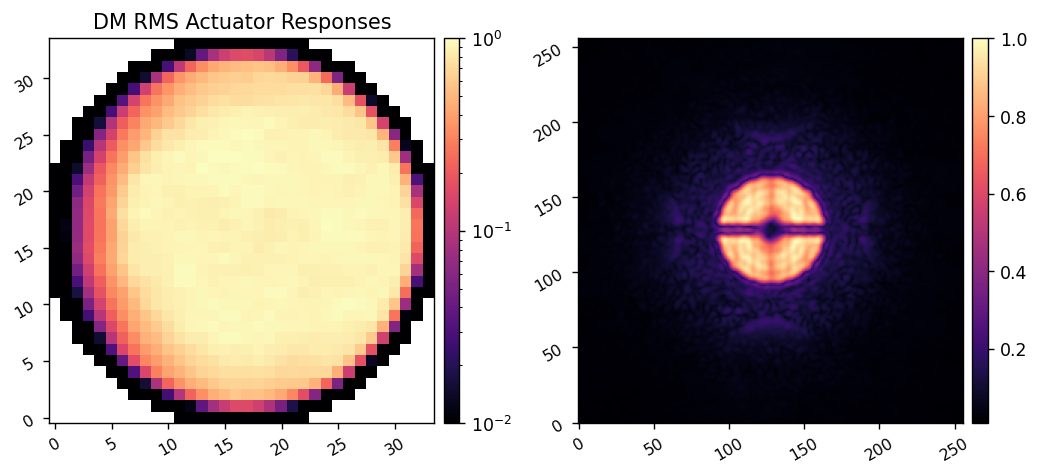

In [21]:
reload(iefc)
M.reset_dm()

probe_amp = 1e-9
calib_amp = 1e-9

response_matrix, response_cube = iefc.calibrate(
    M, 
    control_mask, 
    probe_amp, fourier_probes, 
    calib_amp, calib_modes[:], 
    plot_responses=True,
    channel=3,
)

Calibrating iEFC...


	Calibrated mode 1024/1024 in 124.900s
Calibration complete.


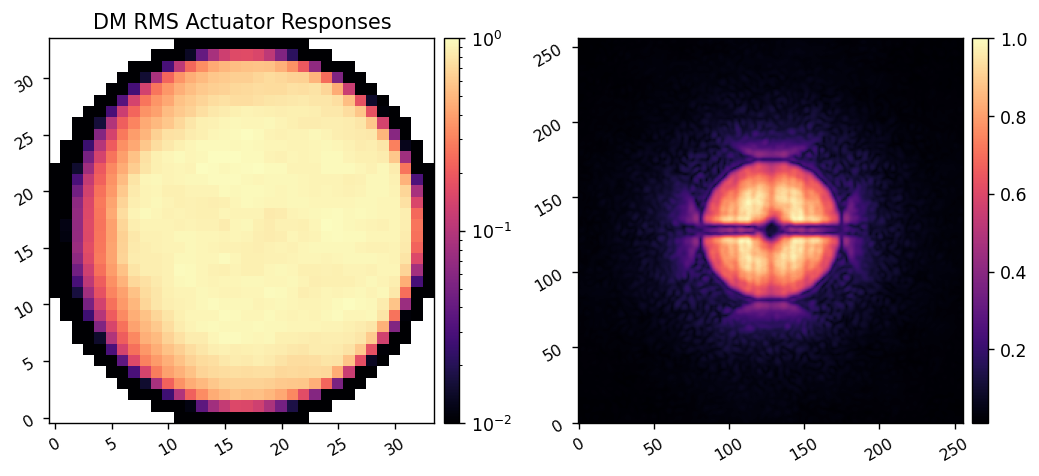

In [8]:
reload(iefc)
M.reset_dm()

probe_amp = 1e-9
calib_amp = 1e-9

response_matrix, response_cube = iefc.calibrate(
    M, 
    control_mask, 
    probe_amp, fourier_probes, 
    calib_amp, calib_modes[:], 
    plot_responses=True,
)

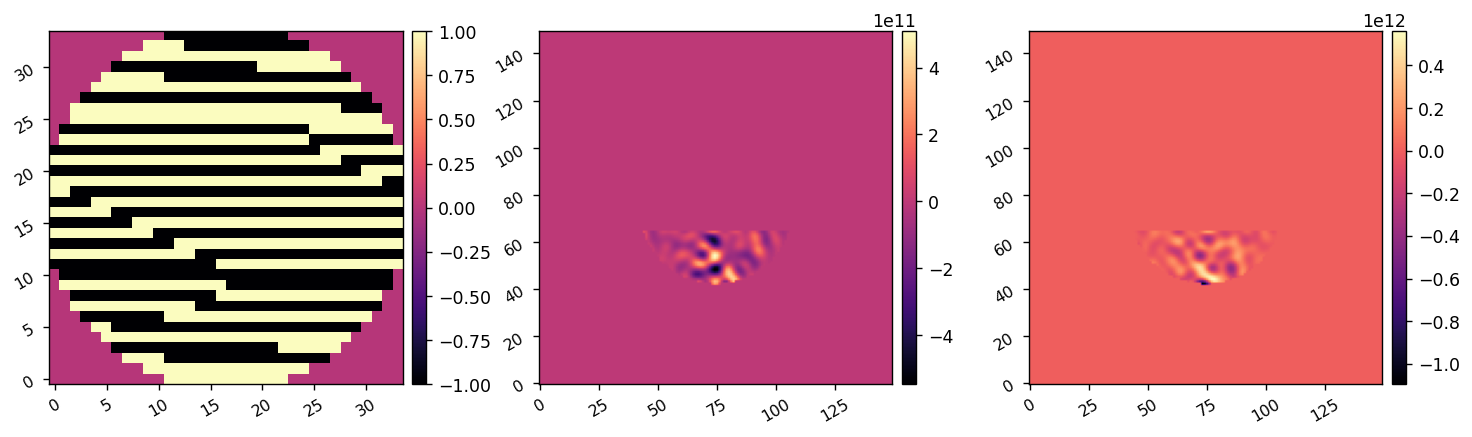

In [41]:
Nmask = control_mask.sum()
i = 800
p1_response = xp.zeros_like(camsci_im0)
p1_response[control_mask] = response_matrix[:Nmask, i]
p2_response = xp.zeros_like(camsci_im0)
p2_response[control_mask] = response_matrix[Nmask:, i]
imshow3(calib_modes[i], p1_response, p2_response)

In [22]:
reload(utils)
cm20 = utils.beta_reg(response_matrix, -2)
cm25 = utils.beta_reg(response_matrix, -2.5)
cm30 = utils.beta_reg(response_matrix, -3)
cm35 = utils.beta_reg(response_matrix, -3.5)
cm40 = utils.beta_reg(response_matrix, -4)
cm45 = utils.beta_reg(response_matrix, -4.5)
cm50 = utils.beta_reg(response_matrix, -5)

In [23]:
M.reset_dm()
data = {
    'images':[camsci_im0],
    'contrasts':[mean_contrast0],
    'commands':[],
    'del_commands':[],
    'pixelscale':M.camsci_pxscl_lamD,
    'control_mask':control_mask, 
    'probes':fourier_probes,
}

Running iEFC...
	Closed-loop iteration 13 / 15


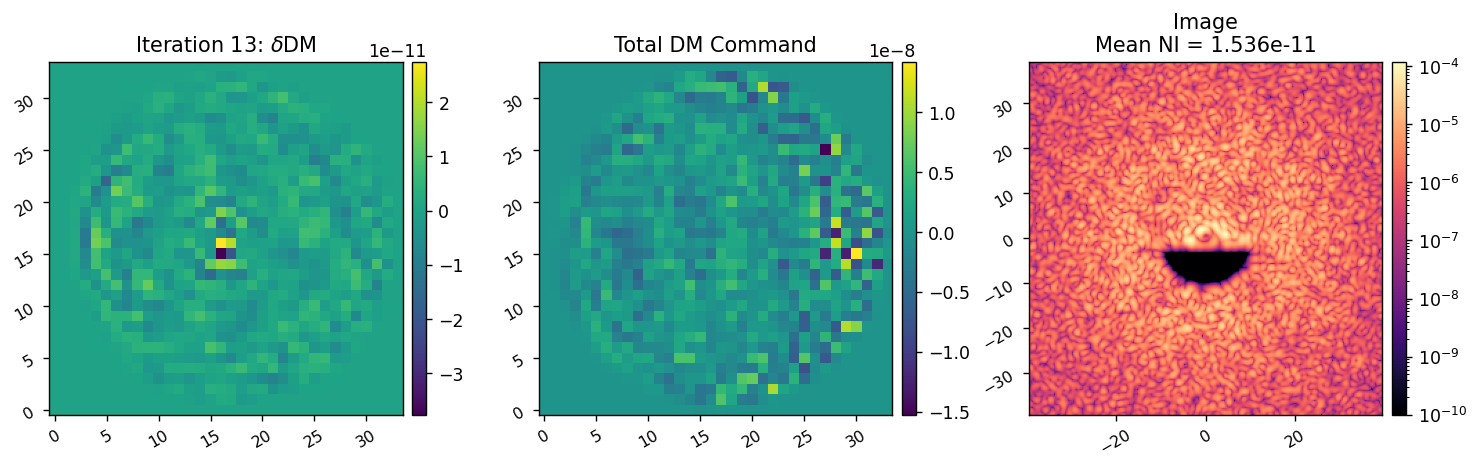

	Closed-loop iteration 14 / 15


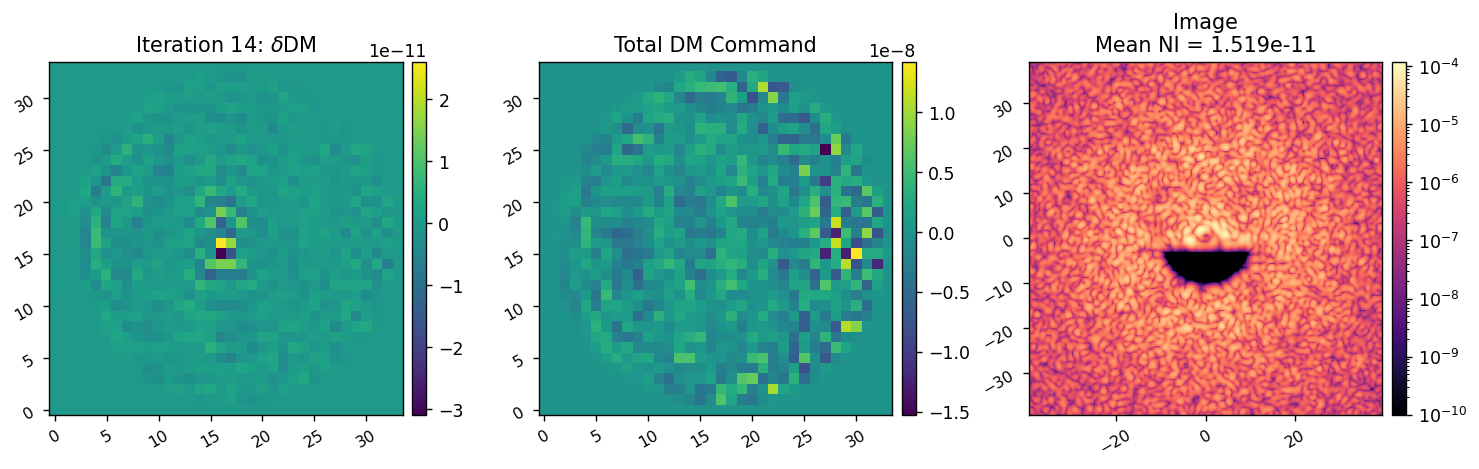

	Closed-loop iteration 15 / 15


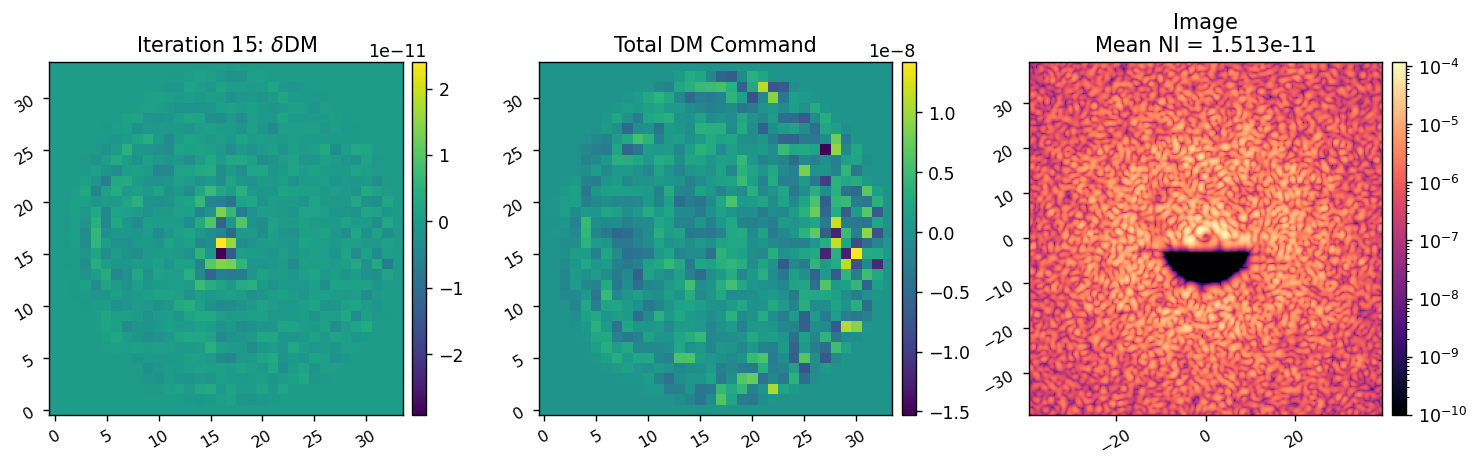

Closed loop for given control matrix completed in 2.319s.


In [28]:
reload(utils)
reload(iefc)

probe_amp = 2.5e-9
probe_amp = 1e-9
probe_amp = 0.25e-9

data = iefc.run(
    M,
    data,
    # cm20,
    cm25,
    # cm40,
    # cm45,
    # cm50,
    fourier_probes, 
    probe_amp, 
    calib_modes,
    control_mask,
    channel=3,
    num_iterations=3,
    gain=1, 
    leakage=0.0,
    plot_current=True,
    plot_all=True,
    plot_probes=False,
    vmin=1e-10,
)

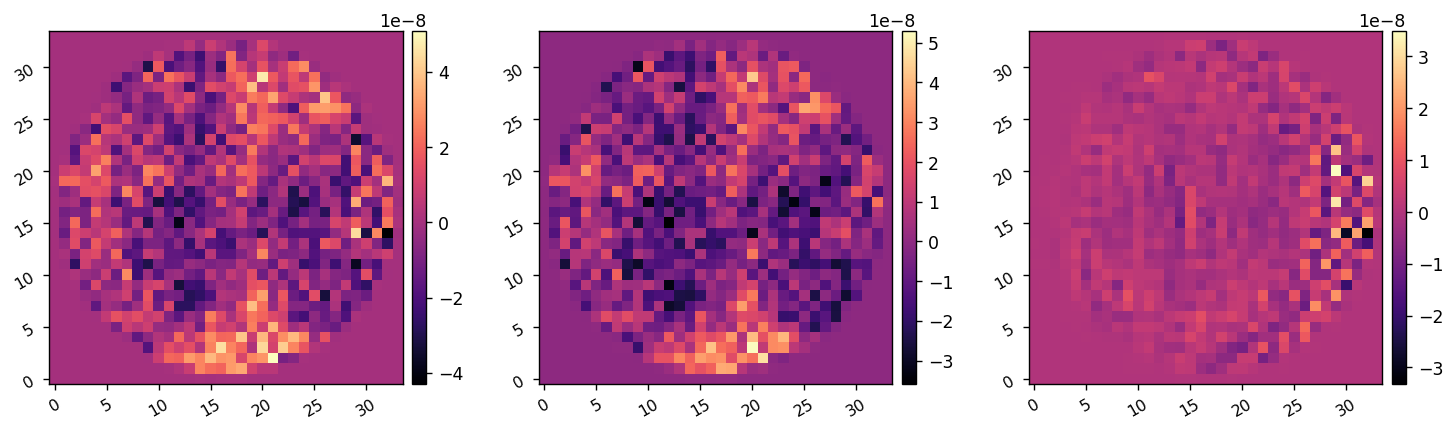

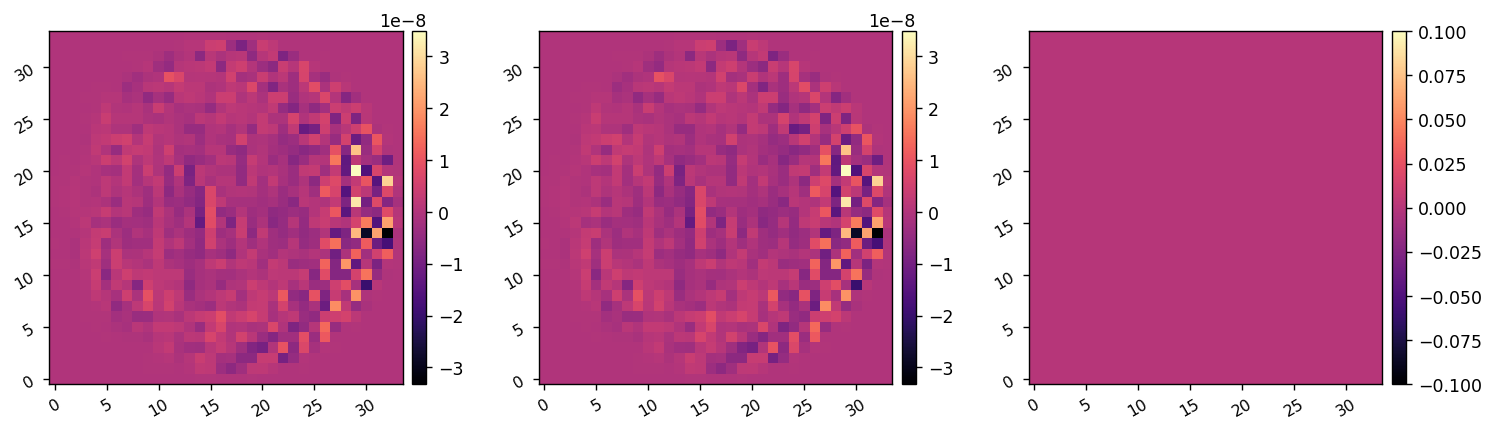

In [46]:
imshow3(M.dm_total, M.get_dm(0), M.get_dm(3))
imshow3(M.get_dm(3), data['commands'][-1], M.get_dm(3)-data['commands'][-1])

In [33]:
utils.save_pickle('sim-data/example_iefc_data.pkl', data)

Saved data to:  sim-data/example_iefc_data.pkl


In [2]:
old_data = utils.load_pickle('sim-data/example_iefc_data.pkl')

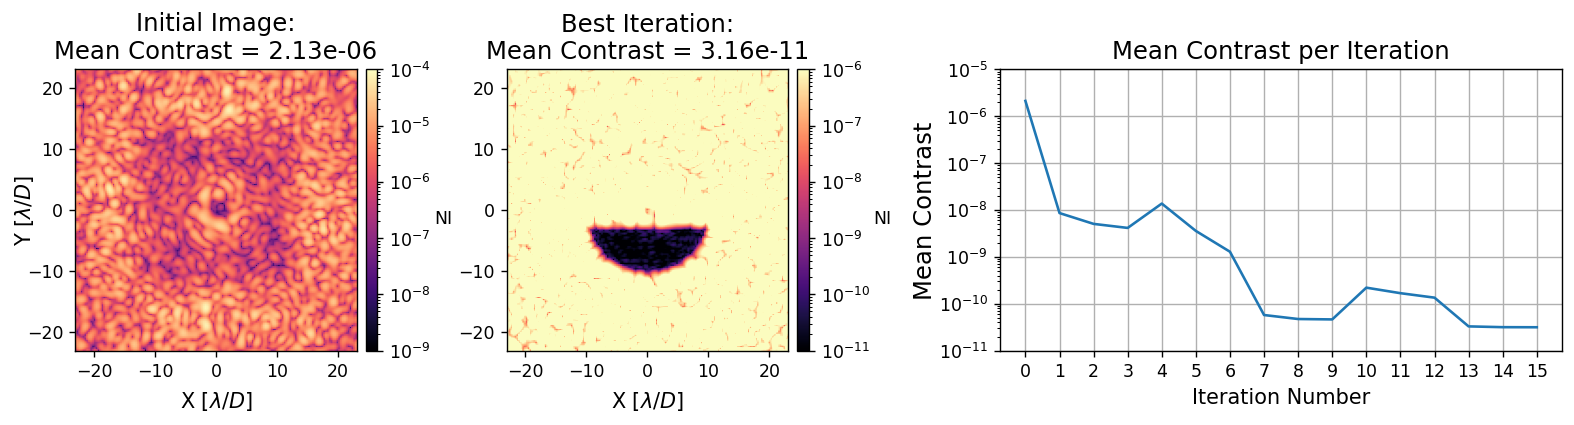

In [14]:
from scoob_llowfsc import imshows
reload(imshows)

imshows.plot_data_with_ref(
    old_data,
    im1vmin=1e-9, im1vmax=1e-4,
    im2vmin=1e-11, im2vmax=1e-6,
    vmin=1e-11, vmax=1e-5,
    xticks=np.arange(0,15+1,1),
)

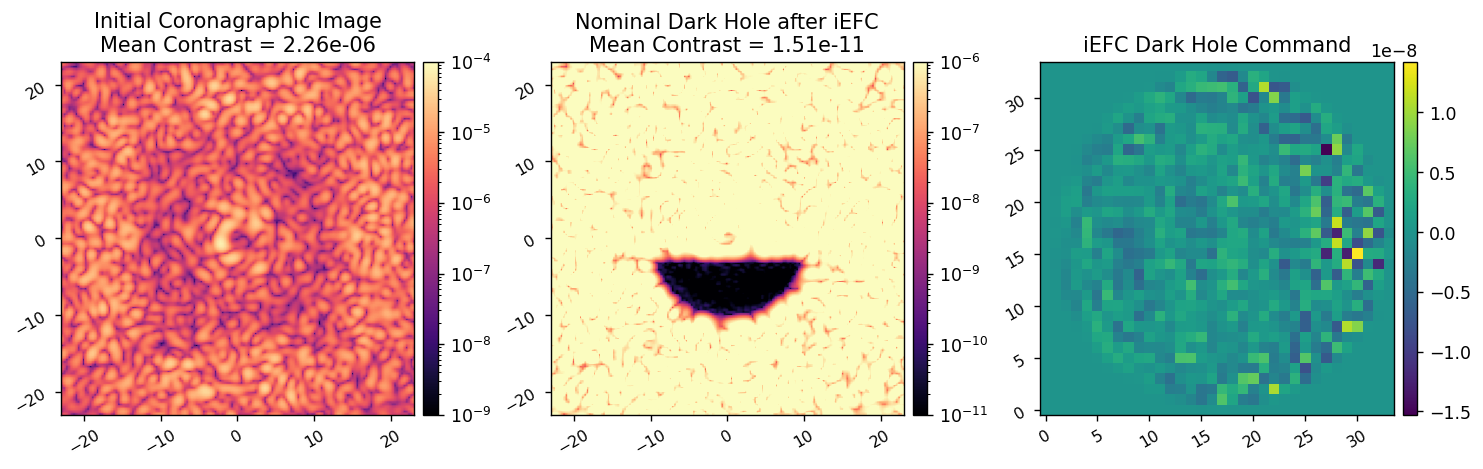

In [14]:
from scoob_llowfsc import imshows
reload(imshows)
imshows.imshow3(
    old_data['images'][0],
    old_data['images'][-1],
    old_data['commands'][-1],
    f'Initial Coronagraphic Image\nMean Contrast = {old_data["contrasts"][0]:.2e}', 
    f'Nominal Dark Hole after iEFC\nMean Contrast = {old_data["contrasts"][-1]:.2e}',
    'iEFC Dark Hole Command',
    lognorm1=1,
    vmin1=1e-9, vmax1=1e-4,
    lognorm2=1,
    vmin2=1e-11, vmax2=1e-6,
    cmap3='viridis',
    pxscl1=old_data['pixelscale'],
    pxscl2=old_data['pixelscale'],
)

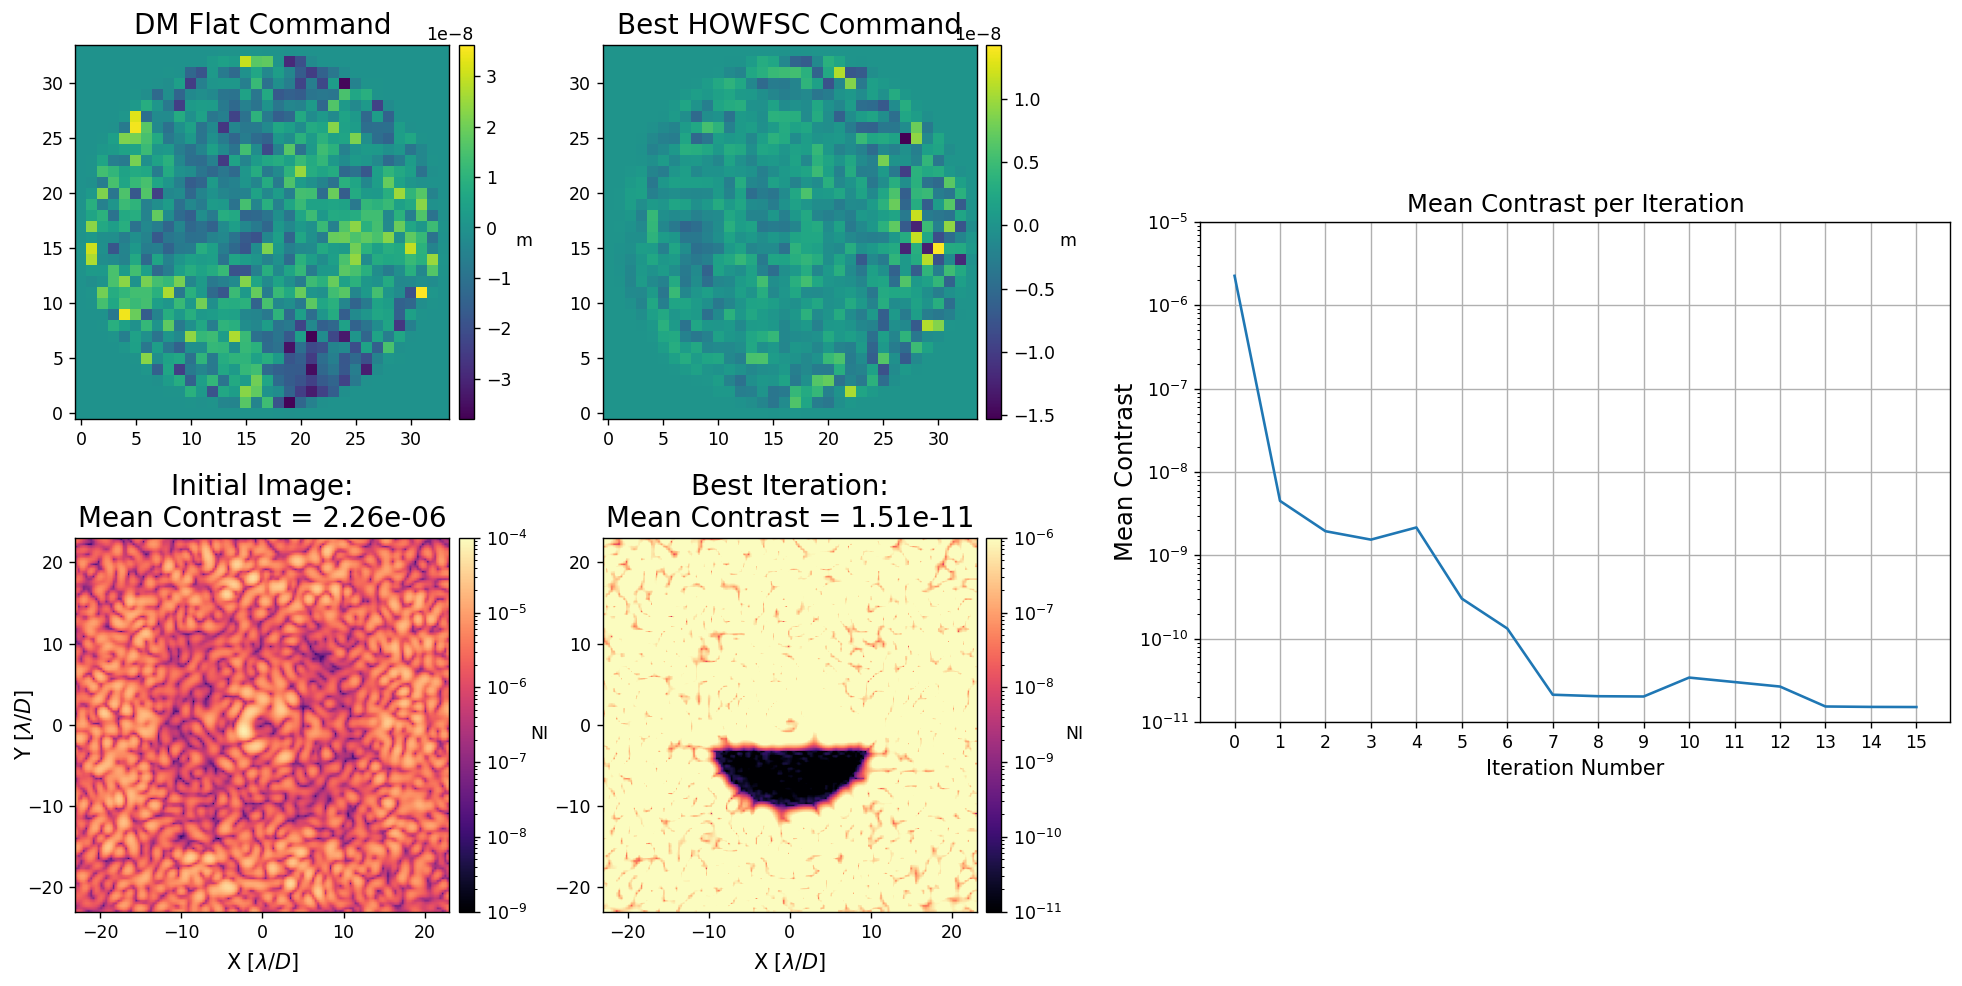

In [3]:
from scoob_llowfsc import imshows
reload(imshows)

imshows.plot_howfsc(
    old_data,
    wfe_data['DM_FLAT'],
    im1vmin=1e-9, im1vmax=1e-4,
    im2vmin=1e-11, im2vmax=1e-6,
    vmin=1e-11, vmax=1e-5,
    xticks=np.arange(0,15+1,1),
    wspace=0.325, 
    hspace=0.05,
    plot_position=[0.725, 0.3, 0.4, 0.4],
    figsize=(15,10), 
    dpi=125,
)